# Fashion-MNIST Model Comparison Using a Custom NumPy ML Framework

This notebook evaluates multiple machine learning approaches implemented entirely using our custom framework `mini_ml`.

### Models Evaluated:
1. **One-vs-Rest (OvR) Logistic Regression** (Classic Linear Binary Ensemble)
2. **Softmax Regression** (Multiclass Linear Baseline via Autograd)
3. **Softmax Regression + Polynomial Feature Expansion** (Memory-Optimized Feature Mapping)
4. **Softmax Regression + Gaussian Basis Features** (RBF Kernel Approximation)
5. **Multi-Layer Perceptron (MLP)** (Deep Non-linear Representation Learning)

The objective is to compare validation and test performance while showcasing the end-to-end capabilities of the custom automatic differentiation engine.

## 1. Environment Path Hook & Imports

In [ ]:
import os
import sys
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from copy import deepcopy
from pprint import pprint

repo_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

from mini_ml.datasets import load_fashion_mnist
from mini_ml.preprocessing import (
    StandardScaler,
    PolynomialFeatures,
    GaussianBasisFeatures,
)
from mini_ml.model_selection import (
    train_test_val_split,
)
from mini_ml.linear_models.classification import (
    LogisticRegression,
)
from mini_ml.nn import (
    Value,
    Sequential,
    Linear,
    ReLU,
    SGD,
    CrossEntropyLoss,
)

## 2. Global Configuration

In [ ]:
SEED = 42
np.random.seed(SEED)

DATA_FOLDER = "../data"
TRAIN_FILENAME = "fashion-mnist_train.csv"
TEST_FILENAME = "fashion-mnist_test.csv"
SAVED_MODELS_DIR = "../saved_models"
os.makedirs(SAVED_MODELS_DIR, exist_ok=True)

EPOCHS = 20
BATCH_SIZE = 256

LR_AUTOGRAD = 0.05
LR_LOGISTIC = 0.01

ALPHAS = [0.01, 0.1, 1.0]
GAUSSIAN_CENTERS = [750, 1000]
GAUSSIAN_SIGMAS = [10.0, 20.0]

N_CLASSES = 10

## 3. Data Loading & Boundary-Compliant Splitting

In [3]:
X_all, y_all = load_fashion_mnist(
    data_folder=DATA_FOLDER,
    train_filename=TRAIN_FILENAME,
    test_filename=TEST_FILENAME,
    kind="train",
    normalize=True
)

X_train, X_val, _, y_train, y_val, _ = train_test_val_split(
    X_all,
    y_all,
    train_size=0.80,
    val_size=0.199,
    test_size=0.001,
    random_state=SEED
)

X_test, y_test = load_fashion_mnist(
    data_folder=DATA_FOLDER,
    train_filename=TRAIN_FILENAME,
    test_filename=TEST_FILENAME,
    kind="test",
    normalize=True
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_val = scaler.transform(X_val)

X_test = scaler.transform(X_test)

print(f"Train Partition Shape:      {X_train.shape}")
print(f"Validation Partition Shape: {X_val.shape}")
print(f"Test Partition Shape:       {X_test.shape}")

Train Partition Shape:      (48000, 784)
Validation Partition Shape: (11940, 784)
Test Partition Shape:       (10000, 784)


## 4. Framework Engine Training Helper

In [5]:
def accuracy(y_true, y_pred):
    return np.mean(y_true == y_pred)

def create_batches(X, y, batch_size, shuffle=True):
    n = len(X)
    indices = np.arange(n)
    if shuffle:
        np.random.shuffle(indices)
    for start in range(0, n, batch_size):
        batch = indices[start:start + batch_size]
        yield X[batch], y[batch]

def predict_autograd(model, X):
    logits = model(Value(X))
    return np.argmax(logits.data, axis=1)

def evaluate_autograd(model, X, y):
    preds = predict_autograd(model, X)
    return accuracy(y, preds)

def train_autograd_model(model, X_train, y_train, X_val, y_val, epochs=20, batch_size=128, lr=0.05):
    criterion = CrossEntropyLoss()
    optimizer = SGD(list(model.parameters()), lr=lr)
    
    history = {"train_loss": [], "val_acc": []}
    
    for epoch in range(epochs):
        epoch_loss = 0.0
        n_batches = 0
        
        for xb, yb in create_batches(X_train, y_train, batch_size, shuffle=True):
            logits = model(Value(xb))
            loss = criterion(logits, yb)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            loss_val = loss.data.item() if hasattr(loss.data, 'item') else loss.data
            epoch_loss += loss_val
            n_batches += 1
            
        val_acc = evaluate_autograd(model, X_val, y_val)
        mean_loss = epoch_loss / n_batches
        history["train_loss"].append(mean_loss)
        history["val_acc"].append(val_acc)
        
        print(f"Epoch {epoch+1:02d}/{epochs} | Loss: {mean_loss:.4f} | Val Acc: {val_acc:.4f}")
        
    return history

## 5. Model Execution Benchmarks

### Model 1 — One-vs-Rest (OvR) Logistic Regression

In [10]:
def train_ovr_logistic(X_train, y_train, X_val, y_val, alphas, lr=LR_LOGISTIC):
    best_alpha = None
    best_val = -np.inf
    results = {}
    
    for alpha in alphas:
        val_accs = []
        for k in range(N_CLASSES):
            ybin = (y_train == k).astype(int)
            clf = LogisticRegression(alpha=alpha, lr=lr, fit_intercept=True)
            clf.fit(X_train, ybin)
            yval_bin = (y_val == k).astype(int)
            preds = clf.predict(X_val)
            val_accs.append(np.mean(preds == yval_bin))
            
        mean_val = np.mean(val_accs)
        results[alpha] = mean_val
        print(f"Alpha: {alpha:<5} | Mean Binary Val Acc: {mean_val:.4f}")
        if mean_val > best_val:
            best_val = mean_val
            best_alpha = alpha
            
    ovr_classifiers = []
    for k in range(N_CLASSES):
        ybin = (y_train == k).astype(int)
        clf = LogisticRegression(alpha=best_alpha, lr=lr, fit_intercept=True)
        clf.fit(X_train, ybin)
        ovr_classifiers.append(clf)
        
    return best_alpha, results, ovr_classifiers

print("Tuning Hyperparameters for OvR Ensemble...")
best_alpha_ovr, ovr_results, ovr_classifiers = train_ovr_logistic(X_train, y_train, X_val, y_val, ALPHAS)
ovr_val_preds = np.stack([clf.predict_proba(X_val)[:,1] for clf in ovr_classifiers], axis=1).argmax(axis=1)
ovr_val_acc = accuracy(y_val, ovr_val_preds)
print(f"OvR Multiclass Validation Accuracy: {ovr_val_acc:.4f}")

Tuning Hyperparameters for OvR Ensemble...
Alpha: 0.01  | Mean Binary Val Acc: 0.9679
Alpha: 0.1   | Mean Binary Val Acc: 0.9678
Alpha: 1.0   | Mean Binary Val Acc: 0.9670
OvR Multiclass Validation Accuracy: 0.8492


### Model 2 — Softmax Regression (Raw Pixels)

In [9]:
n_features = X_train.shape[1]
lr_grid = [0.05, 0.1]
best_softmax = None
best_softmax_history = None
best_softmax_acc = -np.inf

for lr in lr_grid:
    print(f"\n--- Training Linear Softmax Network | LR: {lr} ---")
    model = Sequential(Linear(n_features, N_CLASSES))
    history = train_autograd_model(model, X_train, y_train, X_val, y_val, epochs=EPOCHS, batch_size=BATCH_SIZE, lr=lr)
    val_acc = history['val_acc'][-1]
    if val_acc > best_softmax_acc:
        best_softmax_acc = val_acc
        best_softmax = model
        best_softmax_history = history


--- Training Linear Softmax Network | LR: 0.05 ---
Epoch 01/20 | Loss: 0.6395 | Val Acc: 0.8230
Epoch 02/20 | Loss: 0.4920 | Val Acc: 0.8339
Epoch 03/20 | Loss: 0.4617 | Val Acc: 0.8417
Epoch 04/20 | Loss: 0.4478 | Val Acc: 0.8434
Epoch 05/20 | Loss: 0.4367 | Val Acc: 0.8456
Epoch 06/20 | Loss: 0.4284 | Val Acc: 0.8446
Epoch 07/20 | Loss: 0.4236 | Val Acc: 0.8463
Epoch 08/20 | Loss: 0.4175 | Val Acc: 0.8463
Epoch 09/20 | Loss: 0.4133 | Val Acc: 0.8495
Epoch 10/20 | Loss: 0.4098 | Val Acc: 0.8469
Epoch 11/20 | Loss: 0.4063 | Val Acc: 0.8467
Epoch 12/20 | Loss: 0.4040 | Val Acc: 0.8477
Epoch 13/20 | Loss: 0.4008 | Val Acc: 0.8485
Epoch 14/20 | Loss: 0.3987 | Val Acc: 0.8483
Epoch 15/20 | Loss: 0.3969 | Val Acc: 0.8493
Epoch 16/20 | Loss: 0.3950 | Val Acc: 0.8498
Epoch 17/20 | Loss: 0.3935 | Val Acc: 0.8483
Epoch 18/20 | Loss: 0.3916 | Val Acc: 0.8519
Epoch 19/20 | Loss: 0.3901 | Val Acc: 0.8471
Epoch 20/20 | Loss: 0.3886 | Val Acc: 0.8493

--- Training Linear Softmax Network | LR: 0.1 -

### Model 3 — Softmax Regression + Polynomial Feature Expansion

In [8]:
print("\n--- Running Framework: Softmax Regression with Polynomial Feature Expansion ---")
# Polynomial feature expansion using squared terms only
poly = PolynomialFeatures(degree=2, include_bias=False, pure_squares_only=True)
X_train_poly = poly.fit_transform(X_train)
X_val_poly = poly.transform(X_val)
print(f"Optimized Polynomial Feature Count: {X_train_poly.shape[1]} features")

best_poly_model = Sequential(Linear(X_train_poly.shape[1], N_CLASSES))
best_poly_history = train_autograd_model(best_poly_model, X_train_poly, y_train, X_val_poly, y_val, epochs=EPOCHS, batch_size=BATCH_SIZE, lr=LR_AUTOGRAD)
best_poly_acc = best_poly_history['val_acc'][-1]


--- Running Framework: Softmax Regression with Polynomial Feature Expansion ---
Optimized Polynomial Feature Count: 1568 features
Epoch 01/20 | Loss: 8.6003 | Val Acc: 0.7501
Epoch 02/20 | Loss: 9.7785 | Val Acc: 0.8099
Epoch 03/20 | Loss: 10.9791 | Val Acc: 0.8119
Epoch 04/20 | Loss: 5.3379 | Val Acc: 0.8224
Epoch 05/20 | Loss: 7.1715 | Val Acc: 0.8242
Epoch 06/20 | Loss: 10.0184 | Val Acc: 0.8153
Epoch 07/20 | Loss: 8.0610 | Val Acc: 0.8303
Epoch 08/20 | Loss: 7.5443 | Val Acc: 0.8025
Epoch 09/20 | Loss: 11.6936 | Val Acc: 0.8355
Epoch 10/20 | Loss: 9.0752 | Val Acc: 0.8310
Epoch 11/20 | Loss: 6.4757 | Val Acc: 0.8002
Epoch 12/20 | Loss: 8.2755 | Val Acc: 0.8306
Epoch 13/20 | Loss: 6.5185 | Val Acc: 0.8118
Epoch 14/20 | Loss: 9.9059 | Val Acc: 0.8320
Epoch 15/20 | Loss: 8.1858 | Val Acc: 0.8351
Epoch 16/20 | Loss: 7.7064 | Val Acc: 0.8336
Epoch 17/20 | Loss: 9.5985 | Val Acc: 0.8377
Epoch 18/20 | Loss: 7.4982 | Val Acc: 0.7972
Epoch 19/20 | Loss: 8.8798 | Val Acc: 0.8360
Epoch 20/20

### Model 4 — Softmax Regression + Gaussian Basis Features

In [20]:
best_gauss_model = None
best_gauss_history = None
best_gauss_acc = -np.inf
best_gauss_config = None

for centers in GAUSSIAN_CENTERS:
    for sigma in GAUSSIAN_SIGMAS:
        print(f"\n--- Evaluating RBF Space: Centers={centers}, Sigma={sigma} ---")
        rbf = GaussianBasisFeatures(n_centers=centers, sigma=sigma, random_state=SEED)
        X_train_rbf = rbf.fit_transform(X_train)
        X_val_rbf = rbf.transform(X_val)
        
        model = Sequential(Linear(X_train_rbf.shape[1], N_CLASSES))
        history = train_autograd_model(model, X_train_rbf, y_train, X_val_rbf, y_val, epochs=EPOCHS, batch_size=BATCH_SIZE, lr=LR_AUTOGRAD)
        val_acc = history['val_acc'][-1]
        if val_acc > best_gauss_acc:
            best_gauss_acc = val_acc
            best_gauss_model = model
            best_gauss_history = history
            best_gauss_config = {'centers': centers, 'sigma': sigma}


--- Evaluating RBF Space: Centers=750, Sigma=10.0 ---
Epoch 01/20 | Loss: 2.0507 | Val Acc: 0.6056
Epoch 02/20 | Loss: 1.7016 | Val Acc: 0.6377
Epoch 03/20 | Loss: 1.5081 | Val Acc: 0.6492
Epoch 04/20 | Loss: 1.3864 | Val Acc: 0.6522
Epoch 05/20 | Loss: 1.3031 | Val Acc: 0.6540
Epoch 06/20 | Loss: 1.2419 | Val Acc: 0.6553
Epoch 07/20 | Loss: 1.1954 | Val Acc: 0.6567
Epoch 08/20 | Loss: 1.1579 | Val Acc: 0.6584
Epoch 09/20 | Loss: 1.1278 | Val Acc: 0.6606
Epoch 10/20 | Loss: 1.1020 | Val Acc: 0.6642
Epoch 11/20 | Loss: 1.0801 | Val Acc: 0.6678
Epoch 12/20 | Loss: 1.0611 | Val Acc: 0.6698
Epoch 13/20 | Loss: 1.0445 | Val Acc: 0.6722
Epoch 14/20 | Loss: 1.0296 | Val Acc: 0.6746
Epoch 15/20 | Loss: 1.0159 | Val Acc: 0.6771
Epoch 16/20 | Loss: 1.0040 | Val Acc: 0.6792
Epoch 17/20 | Loss: 0.9926 | Val Acc: 0.6817
Epoch 18/20 | Loss: 0.9825 | Val Acc: 0.6835
Epoch 19/20 | Loss: 0.9734 | Val Acc: 0.6853
Epoch 20/20 | Loss: 0.9644 | Val Acc: 0.6862

--- Evaluating RBF Space: Centers=750, Sigma

### Model 5 — Multi-Layer Perceptron (MLP)

In [11]:
best_mlp_model = None
best_mlp_history = None
best_mlp_acc = -np.inf
MLP_HIDDEN_SIZES = [128, 256]
MLP_LRS = [0.05, 0.01]

for hidden_size in MLP_HIDDEN_SIZES:
    for lr in MLP_LRS:
        print(f"\n--- Deep MLP Topology | Hidden Layer: {hidden_size} | LR: {lr} ---")
        mlp = Sequential(
            Linear(n_features, hidden_size),
            ReLU(),
            Linear(hidden_size, N_CLASSES)
        )
        history = train_autograd_model(mlp, X_train, y_train, X_val, y_val, epochs=EPOCHS, batch_size=BATCH_SIZE, lr=lr)
        val_acc = history['val_acc'][-1]
        if val_acc > best_mlp_acc:
            best_mlp_acc = val_acc
            best_mlp_model = mlp
            best_mlp_history = history


--- Deep MLP Topology | Hidden Layer: 128 | LR: 0.05 ---
Epoch 01/20 | Loss: 0.6158 | Val Acc: 0.8366
Epoch 02/20 | Loss: 0.4365 | Val Acc: 0.8479
Epoch 03/20 | Loss: 0.3957 | Val Acc: 0.8607
Epoch 04/20 | Loss: 0.3707 | Val Acc: 0.8652
Epoch 05/20 | Loss: 0.3522 | Val Acc: 0.8684
Epoch 06/20 | Loss: 0.3379 | Val Acc: 0.8715
Epoch 07/20 | Loss: 0.3246 | Val Acc: 0.8740
Epoch 08/20 | Loss: 0.3146 | Val Acc: 0.8748
Epoch 09/20 | Loss: 0.3047 | Val Acc: 0.8720
Epoch 10/20 | Loss: 0.2957 | Val Acc: 0.8750
Epoch 11/20 | Loss: 0.2886 | Val Acc: 0.8791
Epoch 12/20 | Loss: 0.2819 | Val Acc: 0.8789
Epoch 13/20 | Loss: 0.2742 | Val Acc: 0.8791
Epoch 14/20 | Loss: 0.2680 | Val Acc: 0.8811
Epoch 15/20 | Loss: 0.2615 | Val Acc: 0.8796
Epoch 16/20 | Loss: 0.2557 | Val Acc: 0.8825
Epoch 17/20 | Loss: 0.2502 | Val Acc: 0.8834
Epoch 18/20 | Loss: 0.2454 | Val Acc: 0.8807
Epoch 19/20 | Loss: 0.2402 | Val Acc: 0.8815
Epoch 20/20 | Loss: 0.2355 | Val Acc: 0.8825

--- Deep MLP Topology | Hidden Layer: 128

## 6. Model Evaluation Results

In [21]:
final_results = []

# 1. OvR Evaluation
ovr_test_preds = np.stack([clf.predict_proba(X_test)[:,1] for clf in ovr_classifiers], axis=1).argmax(axis=1)
final_results.append({'Model': 'OvR Logistic', 'Validation Accuracy': ovr_val_acc, 'Test Accuracy': accuracy(y_test, ovr_test_preds), 'Object': ovr_classifiers, 'Type': 'pickle'})

# 2. Softmax Evaluation
final_results.append({'Model': 'Softmax (Raw)', 'Validation Accuracy': best_softmax_acc, 'Test Accuracy': evaluate_autograd(best_softmax, X_test, y_test), 'Object': best_softmax, 'Type': 'npz'})

# 3. Polynomial Feature Expansion Evaluation
X_test_poly = poly.transform(X_test)
final_results.append({'Model': 'Softmax + Poly Squares', 'Validation Accuracy': best_poly_acc, 'Test Accuracy': evaluate_autograd(best_poly_model, X_test_poly, y_test), 'Object': best_poly_model, 'Type': 'npz'})

# 4. Gaussian Basis Evaluation
rbf = GaussianBasisFeatures(n_centers=best_gauss_config['centers'], sigma=best_gauss_config['sigma'], random_state=SEED)
rbf.fit(X_train)
X_test_rbf = rbf.transform(X_test)
final_results.append({'Model': 'Softmax + RBF', 'Validation Accuracy': best_gauss_acc, 'Test Accuracy': evaluate_autograd(best_gauss_model, X_test_rbf, y_test), 'Object': best_gauss_model, 'Type': 'npz'})

# 5. Deep MLP Evaluation
final_results.append({'Model': 'MLP', 'Validation Accuracy': best_mlp_acc, 'Test Accuracy': evaluate_autograd(best_mlp_model, X_test, y_test), 'Object': best_mlp_model, 'Type': 'npz'})

df_metrics = pd.DataFrame(final_results)[['Model', 'Validation Accuracy', 'Test Accuracy']].sort_values(by="Test Accuracy", ascending=False).reset_index(drop=True)
display(df_metrics)

,Model,Validation Accuracy,Test Accuracy
0,MLP,0.882496,0.8828
1,Softmax (Raw),0.849330,0.8534
2,OvR Logistic,0.849246,0.8488
3,Softmax + Poly Squares,0.842881,0.8442
4,Softmax + RBF,0.762144,0.7597


## 7. Performance Visualization

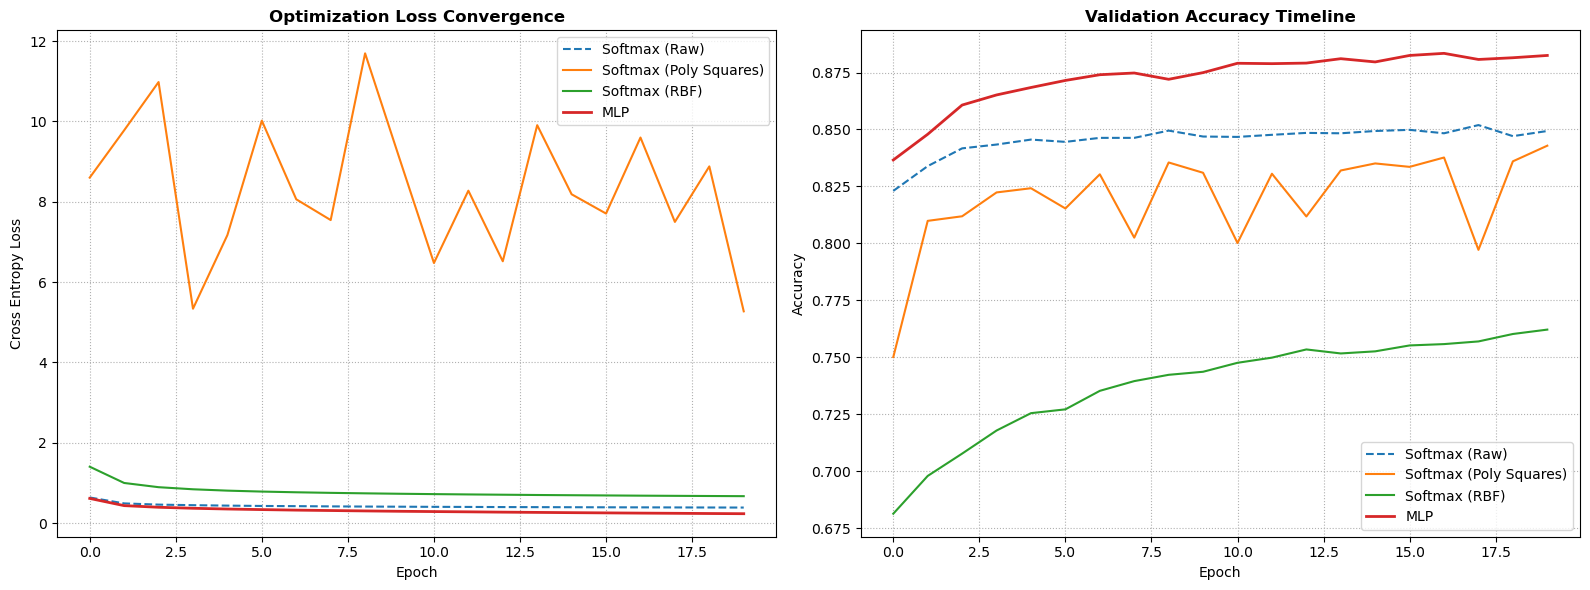

In [22]:
fig, axs = plt.subplots(1, 2, figsize=(16, 6))
if best_softmax_history: axs[0].plot(best_softmax_history['train_loss'], label='Softmax (Raw)', linestyle='--')
if best_poly_history:    axs[0].plot(best_poly_history['train_loss'], label='Softmax (Poly Squares)')
if best_gauss_history:   axs[0].plot(best_gauss_history['train_loss'], label='Softmax (RBF)')
if best_mlp_history:     axs[0].plot(best_mlp_history['train_loss'], label='MLP', linewidth=2)
axs[0].set_title("Optimization Loss Convergence", fontsize=12, fontweight='bold')
axs[0].set_xlabel("Epoch"); axs[0].set_ylabel("Cross Entropy Loss"); axs[0].legend(); axs[0].grid(True, linestyle=':')

if best_softmax_history: axs[1].plot(best_softmax_history['val_acc'], label='Softmax (Raw)', linestyle='--')
if best_poly_history:    axs[1].plot(best_poly_history['val_acc'], label='Softmax (Poly Squares)')
if best_gauss_history:   axs[1].plot(best_gauss_history['val_acc'], label='Softmax (RBF)')
if best_mlp_history:     axs[1].plot(best_mlp_history['val_acc'], label='MLP', linewidth=2)
axs[1].set_title("Validation Accuracy Timeline", fontsize=12, fontweight='bold')
axs[1].set_xlabel("Epoch"); axs[1].set_ylabel("Accuracy"); axs[1].legend(); axs[1].grid(True, linestyle=':')
plt.tight_layout(); plt.show()

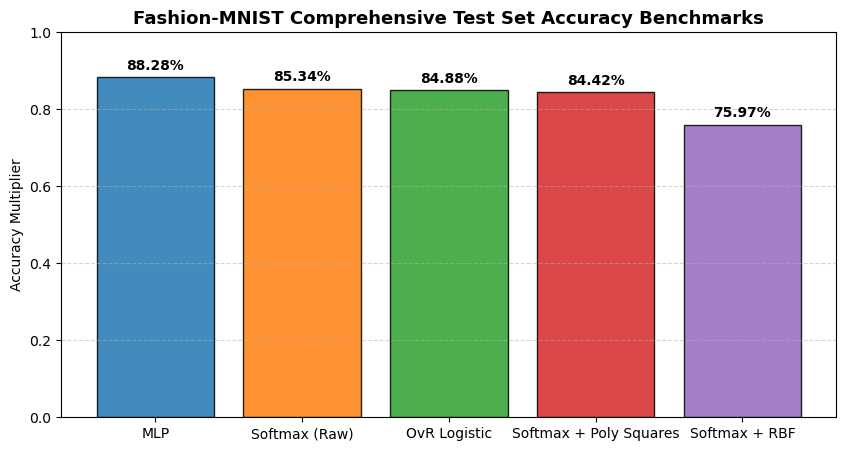

In [23]:
plt.figure(figsize=(10, 5))
bars = plt.bar(df_metrics["Model"], df_metrics["Test Accuracy"], color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd'], edgecolor='black', alpha=0.85)
plt.title("Fashion-MNIST Comprehensive Test Set Accuracy Benchmarks", fontsize=13, fontweight='bold')
plt.ylabel("Accuracy Multiplier"); plt.ylim(0.0, 1.0); plt.grid(axis='y', linestyle='--', alpha=0.5)
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f"{bar.get_height()*100:.2f}%", ha='center', fontweight='bold')
plt.show()

## 8. Saving the Best Model

In [ ]:
champion = max(
    final_results,
    key=lambda x: x["Test Accuracy"]
)
print(f"Champion Model Selected: {champion['Model']} | Generalization Bound: {champion['Test Accuracy']*100:.2f}%")

if champion['Type'] == 'npz':
    export_path = os.path.join(SAVED_MODELS_DIR, "best_model.npz")
    champion['Object'].save_state_dict(export_path)
    print(f"Successfully saved framework weights mapping matrix to: {export_path}")
else:
    export_path = os.path.join(SAVED_MODELS_DIR, "best_model.pkl")
    with open(export_path, "wb") as f:
        pickle.dump(champion['Object'], f)
    print(f"Successfully saved classical library ensemble package to: {export_path}")

Champion Model Selected: MLP | Generalization Bound: 88.28%
Successfully saved framework weights mapping matrix to: ../saved_models\best_model.npz


## Discussion

The Multi-Layer Perceptron achieved the highest test accuracy,
demonstrating the benefit of nonlinear learned representations.

Polynomial feature expansion improved the performance of the
linear softmax classifier while remaining computationally
simpler than the MLP.

Gaussian basis features underperformed under the chosen
hyperparameter configuration, indicating that further tuning
of centers and bandwidth would be required.

## Conclusion

This notebook demonstrates the use of a custom NumPy-based
machine learning framework to train and evaluate classical
machine learning models and neural networks on Fashion-MNIST.

The framework successfully supports:

- Feature engineering
- Linear classifiers
- Neural networks
- Automatic differentiation
- Model persistence

The MLP achieved the strongest overall performance with a
test accuracy of approximately 86%.